In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        '''print(os.path.join(dirname, filename))'''

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [17]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.utils import image_dataset_from_directory

In [18]:
train_dir='/kaggle/input/datasets/samuelcortinhas/cats-and-dogs-image-classification/train'
test_dir='/kaggle/input/datasets/samuelcortinhas/cats-and-dogs-image-classification/test'

In [19]:
import tensorflow as tf
from tensorflow.keras import Sequential, layers
from tensorflow.keras.preprocessing import image_dataset_from_directory

# Load training data with validation split
train_data = image_dataset_from_directory(
    train_dir,
    image_size=(224, 224),
    batch_size=32,
    label_mode='binary',
    shuffle=True,
    validation_split=0.2, 
    subset='training',      # This is training portion
    seed=42                 
)

# we are creating our own validation data, if we have already, we can simply use that
val_data = image_dataset_from_directory(
    train_dir,
    image_size=(224, 224),
    batch_size=32,
    label_mode='binary',
    shuffle=True,
    validation_split=0.2,  
    subset='validation',    
    seed=42                 
)

# Load test data
test_data = image_dataset_from_directory(
    test_dir,
    image_size=(224, 224),
    batch_size=32,
    label_mode='binary',
    shuffle=True
)

Found 557 files belonging to 2 classes.
Using 446 files for training.
Found 557 files belonging to 2 classes.
Using 111 files for validation.
Found 140 files belonging to 2 classes.


In [20]:
from tensorflow.keras import Sequential , layers

model = Sequential([
    layers.Conv2D(32, 3, activation='relu', input_shape=(224, 224, 3)),
    layers.MaxPooling2D(),
    
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    
    layers.Conv2D(128, 3, activation='relu'),
    layers.MaxPooling2D(),
    
    layers.Flatten(),
    
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5),
    
    layers.Dense(1, activation='sigmoid')  
])

In [21]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │    44,302,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,396,609 (169.36 MB)

 Trainable params: 44,396,609 (169.36 MB)

 Non-trainable params: 0 (0.00 B)

In [22]:
history = model.fit(
    train_data,
    epochs=5,
    validation_data=val_data,  
    verbose=1
)

Epoch 1/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 34s 2s/step - accuracy: 0.4357 - loss: 668.5013 - val_accuracy: 0.5225 - val_loss: 1.5643
Epoch 2/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 32s 2s/step - accuracy: 0.5446 - loss: 0.7543 - val_accuracy: 0.5045 - val_loss: 0.7067
Epoch 3/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 32s 2s/step - accuracy: 0.7874 - loss: 0.5130 - val_accuracy: 0.5495 - val_loss: 0.8280
Epoch 4/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 32s 2s/step - accuracy: 0.8650 - loss: 0.3284 - val_accuracy: 0.6396 - val_loss: 1.1166
Epoch 5/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 31s 2s/step - accuracy: 0.9344 - loss: 0.1742 - val_accuracy: 0.5946 - val_loss: 1.4791


In [23]:
import numpy as np

# Evaluate
test_loss, test_accuracy = model.evaluate(test_data)
print(f"\nTest Accuracy: {test_accuracy:.4f}")

5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 447ms/step - accuracy: 0.6377 - loss: 1.2448

Test Accuracy: 0.6357


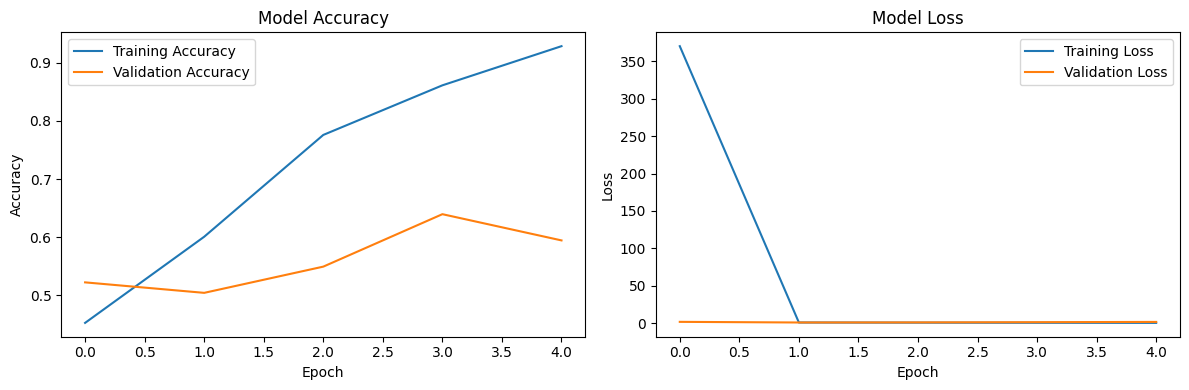

In [24]:
import matplotlib.pyplot as plt

# Then your plotting code
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

FOR DIFFERENT ACTIVATION FUNCTIONS AND OPTIMZER

1) tanh activation function used
2) optimizer - RMSprop changed

In [27]:
from tensorflow.keras import Sequential , layers
from tensorflow.keras.optimizers import RMSprop

model = Sequential([
    layers.Conv2D(32, 3, activation='tanh', input_shape=(224, 224, 3)),
    
    layers.MaxPooling2D(),
    
    layers.Conv2D(64, 3, activation='tanh'),
    layers.MaxPooling2D(),
    
    layers.Conv2D(128, 3, activation='tanh'),
    layers.MaxPooling2D(),
    
    layers.Flatten(),
    
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5),
    
    layers.Dense(1, activation='tanh')  
])

model.compile(
    optimizer=RMSprop(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 512)            │    44,302,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,396,609 (169.36 MB)

 Trainable params: 44,396,609 (169.36 MB)

 Non-trainable params: 0 (0.00 B)

In [28]:
history = model.fit(
    train_data,
    epochs=5,
    validation_data=val_data,  
    verbose=1
)

Epoch 1/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 34s 2s/step - accuracy: 0.5035 - loss: 7.3629 - val_accuracy: 0.5135 - val_loss: 7.7558
Epoch 2/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 41s 2s/step - accuracy: 0.4639 - loss: 8.5472 - val_accuracy: 0.5135 - val_loss: 7.7558
Epoch 3/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 32s 2s/step - accuracy: 0.4550 - loss: 8.6882 - val_accuracy: 0.5135 - val_loss: 7.7558
Epoch 4/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 32s 2s/step - accuracy: 0.5048 - loss: 7.8948 - val_accuracy: 0.5135 - val_loss: 7.7558
Epoch 5/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 41s 2s/step - accuracy: 0.4913 - loss: 8.1092 - val_accuracy: 0.5135 - val_loss: 7.7558


In [29]:
import numpy as np

# Evaluate
test_loss, test_accuracy = model.evaluate(test_data)
print(f"\nTest Accuracy: {test_accuracy:.4f}")

5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 466ms/step - accuracy: 0.5004 - loss: 7.9643

Test Accuracy: 0.5000


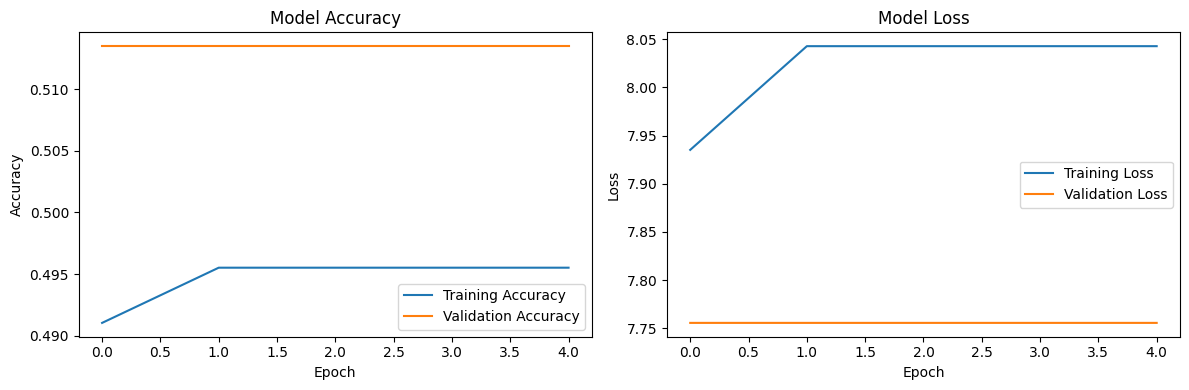

In [30]:
import matplotlib.pyplot as plt

# Then your plotting code
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

For tanh activation the accuracy drops